# Intelligent Methods for Resilience: Household Energy Shifting in DK1

The project investigates how data-driven electricity price signals can support resilience in the Danish electricity grid by helping households shift flexible electricity consumption away from expensive and stressed periods.

The central idea is simple: if households receive understandable recommendations about when electricity is expected to be cheap or expensive, some flexible demand can be moved in time. Examples include electric vehicle charging, dishwashers, washing machines, dryers, and other loads that do not always need to run immediately. At household level the change is small, but at system level many coordinated small shifts can reduce pressure on the grid, lower peaks, and make the electricity system more resilient.

## 1. Research Question and Project Logic

The project asks:

**How can probabilistic electricity price information be translated into household recommendations, and what potential grid-resilience effect can arise if households shift flexible consumption?**

We approach this through four analytical steps:

1. Data scraping and preperation of energy prices, energy demand and weather forecasts
2. Time series forecasting model of energy prices within a 5 days horizon
3. Recommender system for energy usage in households: Dashboard of energy predictions, dynamic LLM recommendations and model explainability (LIME)
4. Model/simulate how much the recommender system shift energy comsumption and the derived impact on the energy grid

The notebook is intentionally written as an explanatory workflow. Most reusable logic is imported from the Python files in `src/`, while the notebook focuses on documenting the choices, showing outputs, and connecting the technical results to the resilience question.

In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.features.feature_engineering import build_feature_matrix, get_feature_columns
from src.recommendations.decision_support import (
    generate_recommendations,
    recommendations_to_dataframe,
    summarise_forecast,
)
from src.data.simulate_impact import (
    load_daily_system_consumption,
    make_daily_prices,
    simulate_daily_shift,
    plot_shift_results,
)

DATA_DIR = Path("data")
PRICE_PATH = DATA_DIR / "day_ahead_prices_dk1_raw.csv"
CONSUMPTION_PATH = DATA_DIR / "consumption_dk1_raw.csv"
SUPPLY_PATH = DATA_DIR / "supply_forecasts_dk1_raw.csv"

plt.style.use("seaborn-v0_8-whitegrid")

## 2. Data Sources

The analysis uses local CSV files scraped from Energi Data Service. The three main files used in this notebook are:

- `data/day_ahead_prices_dk1_raw.csv`: day-ahead electricity prices for price area DK1.
- `data/consumption_dk1_raw.csv`: electricity consumption observations for DK1.
- `data/supply_forecasts_dk1_raw.csv`: production forecasts for offshore wind, onshore wind, and solar power in DK1.

DK1 is relevant because it represents Western Denmark, where electricity prices are strongly affected by wind production, solar production, interconnectors, and changing demand. These conditions make price-based flexibility a meaningful resilience mechanism: when demand can move away from high-price periods, the grid may become less exposed to peak stress and scarcity periods.

In [20]:
prices_raw = pd.read_csv(PRICE_PATH, parse_dates=["TimeDK", "TimeUTC"])
supply_raw = pd.read_csv(SUPPLY_PATH, parse_dates=["HourDK", "HourUTC", "TimestampDK", "TimestampUTC"])
consumption_raw_preview = pd.read_csv(CONSUMPTION_PATH, nrows=10)

display(prices_raw.head())
display(supply_raw.head())
display(consumption_raw_preview.head())

print(f"Price rows: {len(prices_raw):,}")
print(f"Price period: {prices_raw['TimeDK'].min()} to {prices_raw['TimeDK'].max()}")
print(f"Supply rows: {len(supply_raw):,}")
print(f"Supply period: {supply_raw['HourDK'].min()} to {supply_raw['HourDK'].max()}")
print(f"Supply categories: {', '.join(sorted(supply_raw['ForecastType'].unique()))}")

,TimeUTC,TimeDK,PriceArea,DayAheadPriceEUR,DayAheadPriceDKK
0,2026-02-01 22:45:00,2026-02-01 23:45:00,DK1,76.739998,573.048261
1,2026-02-01 22:30:00,2026-02-01 23:30:00,DK1,77.199997,576.483258
2,2026-02-01 22:15:00,2026-02-01 23:15:00,DK1,87.089996,650.335836
3,2026-02-01 22:00:00,2026-02-01 23:00:00,DK1,87.190002,651.082621
4,2026-02-01 21:45:00,2026-02-01 22:45:00,DK1,78.800003,588.431142


,HourUTC,HourDK,PriceArea,ForecastType,ForecastDayAhead,ForecastIntraday,Forecast5Hour,Forecast1Hour,ForecastCurrent,TimestampUTC,TimestampDK
0,2026-02-01 22:00:00,2026-02-01 23:00:00,DK1,Offshore Wind,1007.208313,1006.000000,1020.125000,1063.541626,1083.208374,2026-02-01 22:00:26,2026-02-01 23:00:26
1,2026-02-01 22:00:00,2026-02-01 23:00:00,DK1,Onshore Wind,2188.208252,2263.083252,2458.375000,2900.250000,2908.041748,2026-02-01 22:00:31,2026-02-01 23:00:31
2,2026-02-01 22:00:00,2026-02-01 23:00:00,DK1,Solar,0.000000,0.000000,0.000000,1.424167,6.737083,2026-02-01 21:55:24,2026-02-01 22:55:24
3,2026-02-01 21:00:00,2026-02-01 22:00:00,DK1,Offshore Wind,1008.000000,1005.625000,1017.750000,1059.708374,1082.166626,2026-02-01 21:05:27,2026-02-01 22:05:27
4,2026-02-01 21:00:00,2026-02-01 22:00:00,DK1,Onshore Wind,2239.791748,2284.333252,2458.791748,2862.541748,3029.041748,2026-02-01 21:05:32,2026-02-01 22:05:32


,Date,TimeUTC,TimeDK,PriceArea,GridArea,GridCompanyName,ConsumptionkWh
0,2026-02-01T00:00:00,2026-02-01T22:00:00,2026-02-01T23:00:00,DK1,016,El-net Kongerslev A/S,598.790
1,2026-02-01T00:00:00,2026-02-01T22:00:00,2026-02-01T23:00:00,DK1,031,Nord Energi Net A/S,175217.514
2,2026-02-01T00:00:00,2026-02-01T22:00:00,2026-02-01T23:00:00,DK1,051,Elinord A/S,43051.641
3,2026-02-01T00:00:00,2026-02-01T22:00:00,2026-02-01T23:00:00,DK1,084,Kimbrer Elnet A/S,3348.827
4,2026-02-01T00:00:00,2026-02-01T22:00:00,2026-02-01T23:00:00,DK1,085,Læsø Elnet A/S,2737.520


Price rows: 11,908
Price period: 2025-10-01 00:00:00 to 2026-02-01 23:45:00
Supply rows: 133,321
Supply period: 2021-01-01 00:00:00 to 2026-02-01 23:00:00
Supply categories: Offshore Wind, Onshore Wind, Solar


The raw day-ahead price file contains timestamps, price area, and prices in EUR and DKK. For the rest of the project we use the DKK price because the recommendations and simulation outputs are easier to interpret for Danish households. The raw file may contain sub-hourly observations, so the forecasting feature example below resamples prices to hourly averages before using hourly lags.

The consumption file is larger because it contains grid-area observations. The project code aggregates it to daily system consumption when running the flexibility simulation.

,DKK/MWh
count,11908.000000
mean,670.397648
std,333.366186
min,-37.408167
25%,505.245657
50%,650.443338
75%,784.845719
max,3796.785229


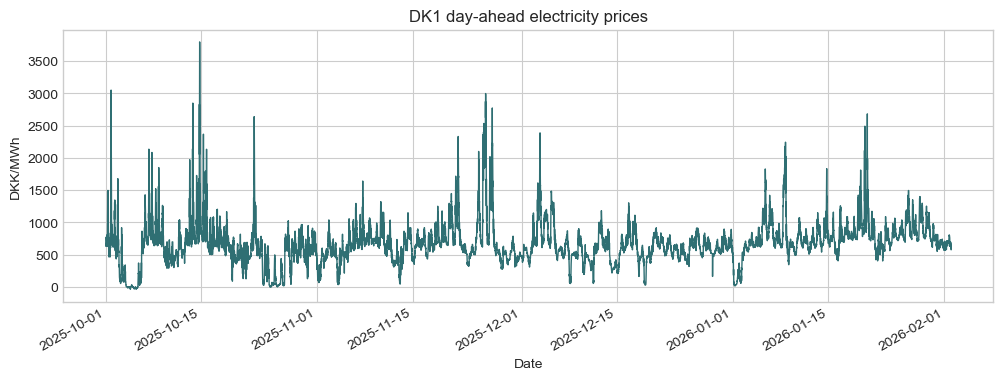

In [21]:
price_summary = prices_raw["DayAheadPriceDKK"].describe().to_frame("DKK/MWh")
display(price_summary)

fig, ax = plt.subplots(figsize=(12, 4))
prices_raw.sort_values("TimeDK").plot(
    x="TimeDK",
    y="DayAheadPriceDKK",
    ax=ax,
    color="#2F6F73",
    linewidth=1,
    legend=False,
)
ax.set_title("DK1 day-ahead electricity prices")
ax.set_xlabel("Date")
ax.set_ylabel("DKK/MWh")
plt.show()

The supply forecast data adds an important explanatory layer to the price data. In DK1, a large part of electricity production is weather-dependent. When forecasted wind and solar production is high, electricity is often more abundant and prices tend to be lower. When renewable supply drops, the system must rely more on other generation, imports, or scarcity pricing, and prices can rise.

This relationship is not perfect, because prices also depend on demand, interconnector flows, fuel prices, and market conditions. Still, the visible connection between supply peaks and price movements suggests that renewable supply forecasts contain useful information for a price forecasting model.

,count,mean,std,min,25%,50%,75%,max
ForecastType,,,,,,,,
Offshore Wind,44173.0,552.164450,316.401766,0.000000,274.250000,557.958313,840.041687,1147.333374
Onshore Wind,44107.0,923.247044,717.536474,5.041667,328.770828,732.916687,1370.250000,3458.958252
Solar,44275.0,219.515738,384.475619,0.000000,0.000000,5.257083,286.277298,2359.466553


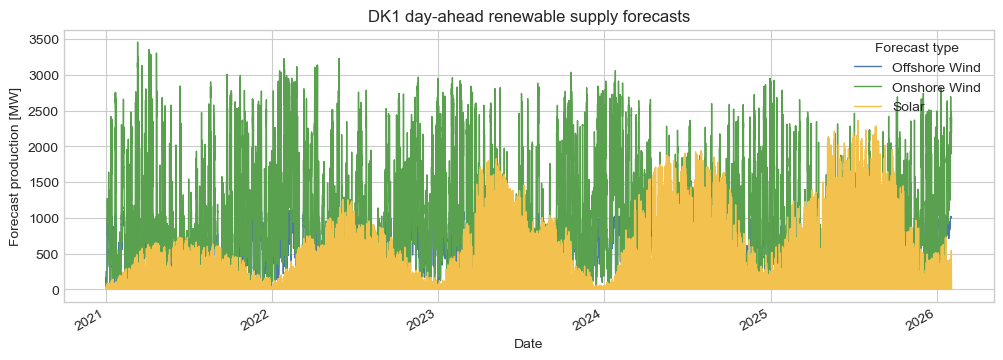

In [22]:
supply_categories = ["Offshore Wind", "Onshore Wind", "Solar"]

supply_hourly = (
    supply_raw[supply_raw["ForecastType"].isin(supply_categories)]
    .pivot_table(
        index="HourDK",
        columns="ForecastType",
        values="ForecastDayAhead",
        aggfunc="mean",
    )
    .sort_index()
)

display(supply_hourly.describe().T)

fig, ax = plt.subplots(figsize=(12, 4))
supply_hourly.plot(
    ax=ax,
    color=["#4C78A8", "#59A14F", "#F2C14E"],
    linewidth=1,
)
ax.set_title("DK1 day-ahead renewable supply forecasts")
ax.set_xlabel("Date")
ax.set_ylabel("Forecast production [MW]")
ax.legend(title="Forecast type")
plt.show()

To make the relationship easier to compare, the next figure combines daily average price with total forecasted renewable supply. The plot uses the same time index for both series and shows the broad trend rather than every short-term fluctuation.

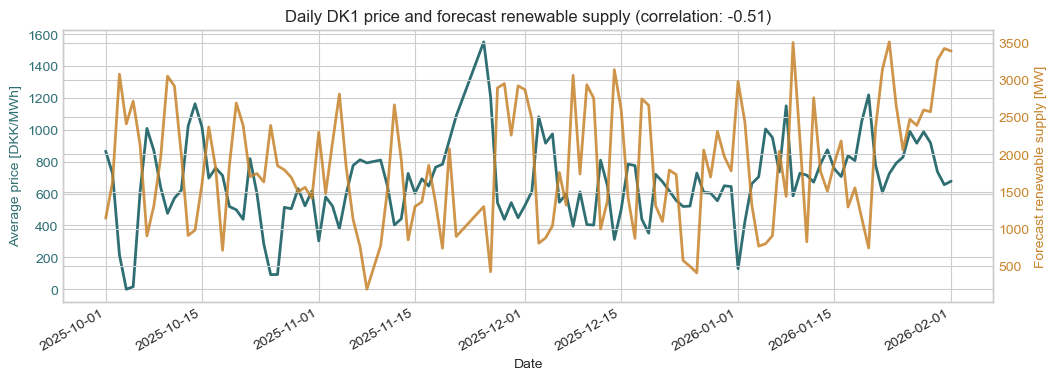

In [23]:
price_daily = (
    prices_raw.set_index("TimeDK")["DayAheadPriceDKK"]
    .resample("D")
    .mean()
    .rename("avg_price_dkk_per_mwh")
)

renewable_daily = (
    supply_hourly.assign(total_renewable_forecast_mw=supply_hourly.sum(axis=1))
    ["total_renewable_forecast_mw"]
    .resample("D")
    .mean()
)

price_supply_daily = pd.concat([price_daily, renewable_daily], axis=1).dropna()
price_supply_corr = price_supply_daily["avg_price_dkk_per_mwh"].corr(
    price_supply_daily["total_renewable_forecast_mw"]
)

fig, ax_price = plt.subplots(figsize=(12, 4))
ax_supply = ax_price.twinx()

price_supply_daily["avg_price_dkk_per_mwh"].plot(
    ax=ax_price,
    color="#2F6F73",
    linewidth=2,
    label="Average price",
)
price_supply_daily["total_renewable_forecast_mw"].plot(
    ax=ax_supply,
    color="#C7832B",
    linewidth=2,
    alpha=0.85,
    label="Forecast renewable supply",
)

ax_price.set_title(
    f"Daily DK1 price and forecast renewable supply (correlation: {price_supply_corr:.2f})"
)
ax_price.set_xlabel("Date")
ax_price.set_ylabel("Average price [DKK/MWh]", color="#2F6F73")
ax_supply.set_ylabel("Forecast renewable supply [MW]", color="#C7832B")
ax_price.tick_params(axis="y", labelcolor="#2F6F73")
ax_supply.tick_params(axis="y", labelcolor="#C7832B")
plt.show()

The figures suggest an economically intuitive pattern: periods with stronger forecasted renewable supply often coincide with lower prices, while periods with weaker wind and solar supply are more likely to coincide with price increases. We should not interpret this as a one-to-one causal rule, but it gives the forecasting model a useful signal.

For the project objective, this is important because households do not need a perfectly exact prediction of every hourly price. They mainly need to know whether the next few days are likely to become cheaper or more expensive. If supply forecasts and recent price patterns can give a reasonable 5-day-ahead price trend, then households can act on that information by delaying flexible consumption to cheaper windows. This is the link between forecasting accuracy and grid resilience: better forward-looking signals can turn household flexibility into a practical response mechanism.

## 3. Feature Engineering for Forecasting

The project uses forecasting as the analytical bridge between raw electricity data and household recommendations. A useful forecast model needs features that capture repeated temporal patterns and recent market behavior.

The feature-engineering code in `src/features/feature_engineering.py` creates:

- calendar variables such as hour, weekday, month, weekend, and Danish holidays,
- cyclical encodings of time variables, so midnight and 23:00 are treated as close in time,
- lagged prices, which capture recent price levels,
- rolling statistics, which describe recent volatility and price regimes,
- price-difference and percentage-change features, which capture short-term trends.

In this draft notebook we demonstrate the feature matrix construction for a 24-hour-ahead target.

In [24]:
hourly_prices = (
    prices_raw.rename(columns={"TimeDK": "HourDK", "DayAheadPriceDKK": "SpotPriceDKK"})
    .sort_values("HourDK")
    .set_index("HourDK")[["SpotPriceDKK"]]
    .resample("h")
    .mean()
    .dropna()
)

features_24h = build_feature_matrix(hourly_prices, forecast_horizon=24, drop_na=True)
feature_columns = get_feature_columns(features_24h)

print(f"Feature matrix shape: {features_24h.shape}")
print(f"Number of model features: {len(feature_columns)}")
display(features_24h.head())

Feature matrix shape: (2784, 51)
Number of model features: 49


c:\Users\rebec\OneDrive\Dokumenter\GitHub\Advanced-Business-Analytics\src\features\feature_engineering.py:54: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df["is_danish_holiday"] = idx.normalize().isin(dk_holidays).astype(int)


,SpotPriceDKK,y,hour,day_of_week,month,year,day_of_year,week_of_year,is_weekend,is_danish_holiday,...,rolling_min_48h,rolling_max_48h,rolling_mean_168h,rolling_std_168h,rolling_min_168h,rolling_max_168h,price_diff_1h,price_diff_24h,price_pct_change_24h,price_pct_change_168h
HourDK,,,,,,,,,,,,,,,,,,,,,
2025-10-08 00:00:00,697.781778,725.903633,0,2,10,2025,281,41,0,0,...,67.965637,2014.15675,491.349555,473.561452,-27.290789,2538.350036,-30.060734,-50.816774,-0.067883,0.020723
2025-10-08 01:00:00,660.336281,691.313686,1,2,10,2025,281,41,0,0,...,67.965637,2014.15675,491.433880,473.597153,-27.290789,2538.350036,-37.445497,-41.393186,-0.058987,0.025056
2025-10-08 02:00:00,653.784248,696.372443,2,2,10,2025,281,41,0,0,...,67.965637,2014.15675,491.529958,473.629965,-27.290789,2538.350036,-6.552033,-16.811177,-0.025069,0.031776
2025-10-08 03:00:00,649.416249,661.241147,3,2,10,2025,281,41,0,0,...,80.136358,2014.15675,491.649807,473.668689,-27.290789,2538.350036,-4.367999,-19.181968,-0.028690,-0.015179
2025-10-08 04:00:00,669.557661,692.172351,4,2,10,2025,281,41,0,0,...,125.440565,2014.15675,491.590228,473.648088,-27.290789,2538.350036,20.141412,-24.612287,-0.035456,0.023126


The target column `y` is the future electricity price at the chosen forecast horizon. For a 24-hour horizon, each row describes what was known at a given hour and links it to the price one day later.

This structure is important for resilience because households need forward-looking information. A recommendation is only useful if it tells the user whether it is better to consume now or wait for a future window.

## 4. From Price Signals to Household Recommendations

Forecasts alone are not enough for most households. A table of predicted prices is technically useful, but it does not automatically answer the practical question: **Should I run this flexible load now or later?**

The recommendation layer in `src/recommendations/decision_support.py` translates a probabilistic forecast into plain-language messages. It identifies cheap and expensive periods relative to recent price levels and highlights the best saving opportunity.

In [25]:
# Draft forecast-like input based on the latest observed prices.
# In the full project this table would come from the trained forecasting model.
forecast_horizons = [1, 3, 6, 12, 24, 48, 72, 96, 120, 144, 168]
latest_prices = hourly_prices.tail(max(forecast_horizons))["SpotPriceDKK"].reset_index(drop=True)

forecast_df = pd.DataFrame(
    {
        "horizon_h": forecast_horizons,
        "q0.10": [latest_prices.iloc[-h] * 0.85 for h in forecast_horizons],
        "q0.50": [latest_prices.iloc[-h] for h in forecast_horizons],
        "q0.90": [latest_prices.iloc[-h] * 1.15 for h in forecast_horizons],
    }
).set_index("horizon_h")

current_price = float(hourly_prices["SpotPriceDKK"].iloc[-1])
recent_history = hourly_prices["SpotPriceDKK"].tail(24 * 30)

forecast_summary = summarise_forecast(forecast_df)
recommendations = generate_recommendations(
    forecast_df,
    current_price_dkk=current_price,
    historical_prices=recent_history,
)

display(pd.Series(forecast_summary, name="forecast_summary"))
display(recommendations_to_dataframe(recommendations))

min_median                  612.737494
max_median                  859.625610
mean_median                 730.431484
cheapest_horizon_h            1.000000
most_expensive_horizon_h    144.000000
price_range_dkk             246.888117
Name: forecast_summary, dtype: float64

,horizon_h,category,message,estimated_saving_dkk_per_mwh,lower_price_dkk,median_price_dkk,upper_price_dkk
0,1,cheap,Electricity is expected to be cheap in 1 hour ...,None,520.8,612.7,704.6
1,3,cheap,Electricity is expected to be cheap in 3 hours...,None,581.2,683.8,786.4


This step connects analytics to behavior. The recommendation does not require the household to understand quantile regression or electricity-market dynamics. Instead, it communicates whether waiting is expected to be valuable and whether an upcoming period looks unusually expensive.

For a real deployment, the forecast table would be produced by the trained price model. In this notebook draft, the same recommendation functions are demonstrated with a forecast-like table so the logic is visible and easy to inspect.

## 5. Model Explainability: LIME

A price forecast is more useful when the user can understand why the model expects prices to rise or fall. For this reason, the project includes model explainability as a separate step. The intended method is **LIME**: Local Interpretable Model-Agnostic Explanations.

LIME explains one prediction at a time. Instead of trying to explain the whole forecasting model globally, it slightly perturbs the input features around a specific forecast observation and learns a simple local surrogate model. The resulting explanation shows which features pushed the prediction upward or downward for that specific forecast. This is suitable for our project because electricity prices depend on many interacting factors, and a household recommendation is based on a particular forecast window rather than an abstract average model behavior.

In the final implementation, this notebook should import a function from a script such as `src/explainability/lime_explainer.py`. The placeholder below keeps the notebook structure ready for that script. Until the LIME script is implemented, the cell creates an illustrative local explanation based on feature-target correlations in the prepared feature matrix.

c:\Users\rebec\miniforge3\Lib\site-packages\numpy\lib\_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
c:\Users\rebec\miniforge3\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,feature,directional_contribution
0,rolling_min_168h,0.437049
1,year,0.409553
2,month,0.398770
3,day_of_year,0.378829
4,hour,0.376704
5,doy_sin,0.342811
6,month_sin,0.298105
7,week_of_year,0.280014
8,hour_cos,-0.268419
9,rolling_min_48h,0.254246


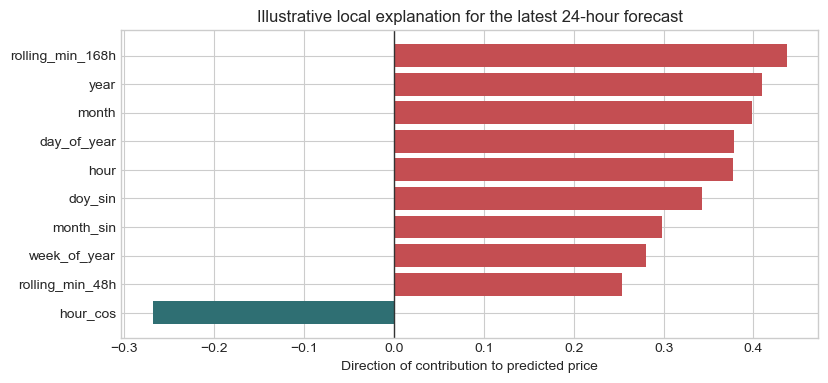

In [26]:
# Planned final import:
# from src.explainability.lime_explainer import explain_forecast_with_lime

try:
    from src.explainability.lime_explainer import explain_forecast_with_lime
    lime_explanation = explain_forecast_with_lime(
        model=None,  # replace with trained forecasting model
        X_train=features_24h[feature_columns],
        observation=features_24h[feature_columns].iloc[-1],
    )
except ModuleNotFoundError:
    # Temporary notebook fallback: a simple local proxy explanation.
    # This is not LIME, but it gives the same type of takeaway table until the script is added.
    numeric_features = features_24h[feature_columns].select_dtypes(include="number")
    feature_corr = numeric_features.corrwith(features_24h["y"]).dropna()
    latest_z = (numeric_features.iloc[-1] - numeric_features.mean()) / numeric_features.std(ddof=0)
    proxy_contribution = (latest_z * feature_corr).dropna().sort_values(key=abs, ascending=False)

    lime_explanation = (
        proxy_contribution.head(10)
        .rename("directional_contribution")
        .reset_index()
        .rename(columns={"index": "feature"})
    )

display(lime_explanation)

fig, ax = plt.subplots(figsize=(9, 4))
plot_df = lime_explanation.sort_values("directional_contribution")
colors = np.where(plot_df["directional_contribution"] >= 0, "#C44E52", "#2F6F73")
ax.barh(plot_df["feature"], plot_df["directional_contribution"], color=colors)
ax.axvline(0, color="#333333", linewidth=1)
ax.set_title("Illustrative local explanation for the latest 24-hour forecast")
ax.set_xlabel("Direction of contribution to predicted price")
plt.show()

The figure should be read as a local explanation of one forecast. Features to the right increase the predicted price for this observation, while features to the left decrease it. In a complete LIME implementation, the bars would come from the LIME surrogate model; in this draft, they are a proxy used to show the intended interpretation.

For the hand-in, the main takeaway is that explainability makes the recommender more trustworthy. If the dashboard says that prices are expected to rise, LIME can show whether that signal is driven by recent high prices, time-of-day effects, weekly patterns, or supply-related variables. This helps connect the prediction to a plausible energy-system explanation.

## 6. Household Recommender System: Dashboard

The dashboard is the user-facing part of the project. Its purpose is to turn the forecasting and recommendation logic into an interface that a household can act on without reading model outputs directly.

The dashboard combines four elements. First, it shows recent and forecasted electricity prices for DK1, so users can see the expected price trend. Second, it shows renewable supply information, because wind and solar production help explain why price levels may change. Third, it presents short recommendations such as whether it is better to use electricity now or wait for a cheaper window. Fourth, it can include model explanation outputs, so the household can see why the system gives a specific recommendation.

The goal is not only to predict prices, but to create a decision-support tool. The household should be able to answer: when should I run flexible consumption, how large is the expected saving, and how confident is the system that the recommendation makes sense?

,dashboard_element,what_it_shows,household_value
0,Price trend,Expected DK1 price level across the next forec...,Helps identify whether electricity use should ...
1,Renewable supply,"Forecasted offshore wind, onshore wind, and so...",Explains why prices may become lower or higher
2,Recommendation cards,"Cheap, normal, or expensive consumption windows",Turns forecasts into concrete actions
3,Model explanation,Most important drivers behind a selected forecast,Improves transparency and trust


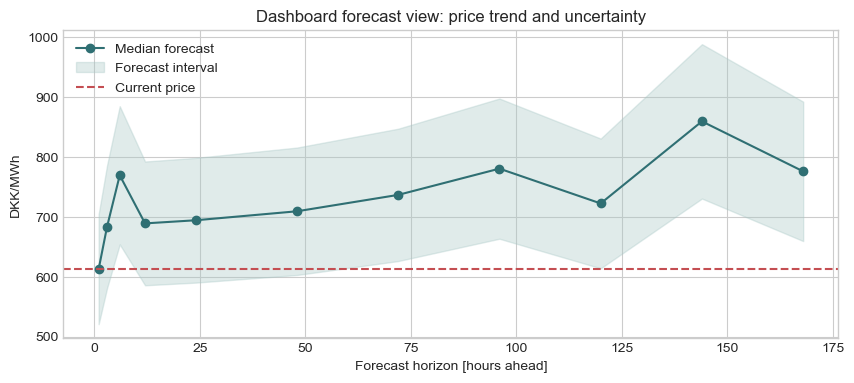

,horizon_h,category,message
0,1,cheap,Electricity is expected to be cheap in 1 hour ...
1,3,cheap,Electricity is expected to be cheap in 3 hours...


In [27]:
dashboard_takeaways = pd.DataFrame(
    [
        {
            "dashboard_element": "Price trend",
            "what_it_shows": "Expected DK1 price level across the next forecast horizons",
            "household_value": "Helps identify whether electricity use should happen now or later",
        },
        {
            "dashboard_element": "Renewable supply",
            "what_it_shows": "Forecasted offshore wind, onshore wind, and solar production",
            "household_value": "Explains why prices may become lower or higher",
        },
        {
            "dashboard_element": "Recommendation cards",
            "what_it_shows": "Cheap, normal, or expensive consumption windows",
            "household_value": "Turns forecasts into concrete actions",
        },
        {
            "dashboard_element": "Model explanation",
            "what_it_shows": "Most important drivers behind a selected forecast",
            "household_value": "Improves transparency and trust",
        },
    ]
)

display(dashboard_takeaways)

fig, ax = plt.subplots(figsize=(10, 4))
forecast_df["q0.50"].plot(ax=ax, marker="o", color="#2F6F73", label="Median forecast")
ax.fill_between(
    forecast_df.index,
    forecast_df["q0.10"],
    forecast_df["q0.90"],
    color="#A7C7C5",
    alpha=0.35,
    label="Forecast interval",
)
ax.axhline(current_price, color="#C44E52", linestyle="--", label="Current price")
ax.set_title("Dashboard forecast view: price trend and uncertainty")
ax.set_xlabel("Forecast horizon [hours ahead]")
ax.set_ylabel("DKK/MWh")
ax.legend()
plt.show()

display(recommendations_to_dataframe(recommendations)[["horizon_h", "category", "message"]])

The dashboard figure shows the central idea of the household recommender. The line represents the expected price trend, while the shaded area communicates uncertainty. The dashed line marks the current price, making it easier to see whether future windows are expected to be cheaper or more expensive than consuming now.

The recommendation table then translates the same information into user language. This is the key design principle: the model produces forecasts, but the dashboard produces decisions. In resilience terms, this helps convert household flexibility from a theoretical resource into a practical action.

## 7. Simulating Household Flexibility and Grid Impact

The next step estimates what could happen if some households respond to the recommendations. The simulation in `src/data/simulate_impact.py` represents household flexibility with a few interpretable assumptions:

- households are a share of total system electricity consumption,
- only part of household load is flexible,
- only part of households respond to recommendations,
- response increases when the price difference between today and a cheaper future day becomes larger,
- shifted demand is moved to a cheaper future day rather than removed completely.

This is not a perfect behavioral model. It is a scenario model that helps us reason about direction and magnitude: if price guidance causes flexible load to move, how much energy moves and how does the daily system profile change?

In [28]:
daily_dates, daily_prices = make_daily_prices(n_days=60, csv_path=PRICE_PATH)
daily_consumption = load_daily_system_consumption(n_days=60, csv_path=CONSUMPTION_PATH)

daily_overview = pd.DataFrame(
    {
        "date": daily_dates,
        "avg_price_dkk_per_mwh": daily_prices,
        "system_daily_consumption": daily_consumption,
    }
)

display(daily_overview.head())
display(daily_overview.describe())

,date,avg_price_dkk_per_mwh,system_daily_consumption
0,2025-12-04,916.237738,7.237062e+07
1,2025-12-05,974.687561,7.062631e+07
2,2025-12-06,545.228921,6.591416e+07
3,2025-12-07,598.197426,6.386500e+07
4,2025-12-08,395.345368,7.876043e+07


,date,avg_price_dkk_per_mwh,system_daily_consumption
count,60,60.000000,6.000000e+01
mean,2026-01-02 12:00:00,699.938818,7.384241e+07
min,2025-12-04 00:00:00,128.632351,5.933045e+07
25%,2025-12-18 18:00:00,595.106331,6.816033e+07
50%,2026-01-02 12:00:00,706.114623,7.424868e+07
75%,2026-01-17 06:00:00,807.645093,8.037536e+07
max,2026-02-01 00:00:00,1219.710045,8.861520e+07
std,NaN,207.113819,7.821704e+06


In [29]:
shift_df, shift_summary = simulate_daily_shift(
    n_days=60,
    seed=42,
    model="logistic",
    lookahead_days=5,
    household_share_of_system=0.35,
    flexible_share_of_household=0.23,
    responsive_household_share=0.33,
)

display(pd.Series(shift_summary, name="logistic_shift_scenario"))
display(shift_df.head())

model                                    logistic
days                                           60
lookahead_days                                  5
avg_price_dkk_per_mwh                  699.938818
shifted_energy_mwh                14577434.435432
baseline_peak_daily_mwh              88615199.448
shifted_peak_daily_mwh            90678112.000249
peak_reduction_daily_mwh          -2062912.552249
residential_cost_savings_dkk    5025717582.297729
residential_cost_savings_pct             0.004613
Name: logistic_shift_scenario, dtype: object

,date,price_today_dkk_per_mwh,forecast_price_dkk_per_mwh,system_daily_energy_baseline_mwh,household_daily_energy_baseline_mwh,household_daily_energy_shifted_mwh,system_daily_energy_shifted_mwh,flexible_daily_energy_mwh,shifted_out_mwh,shifted_in_mwh,best_spread_dkk_per_kwh,chosen_target_day_index
0,2025-12-04,916.237738,932.997177,7.237062e+07,2.532972e+07,2.461892e+07,7.165983e+07,5.825835e+06,710793.492243,0.000000e+00,0.628199,4
1,2025-12-05,974.687561,917.488435,7.062631e+07,2.471921e+07,2.394987e+07,6.985697e+07,5.685418e+06,769339.089429,0.000000e+00,0.686649,4
2,2025-12-06,545.228921,586.503737,6.591416e+07,2.306996e+07,2.282185e+07,6.566605e+07,5.306090e+06,248107.424513,0.000000e+00,0.257190,4
3,2025-12-07,598.197426,649.928485,6.386500e+07,2.235275e+07,2.206917e+07,6.358142e+07,5.141133e+06,283578.922649,0.000000e+00,0.310159,4
4,2025-12-08,395.345368,288.038433,7.876043e+07,2.756615e+07,2.945149e+07,8.064577e+07,6.340215e+06,126482.902563,2.011819e+06,0.010274,7


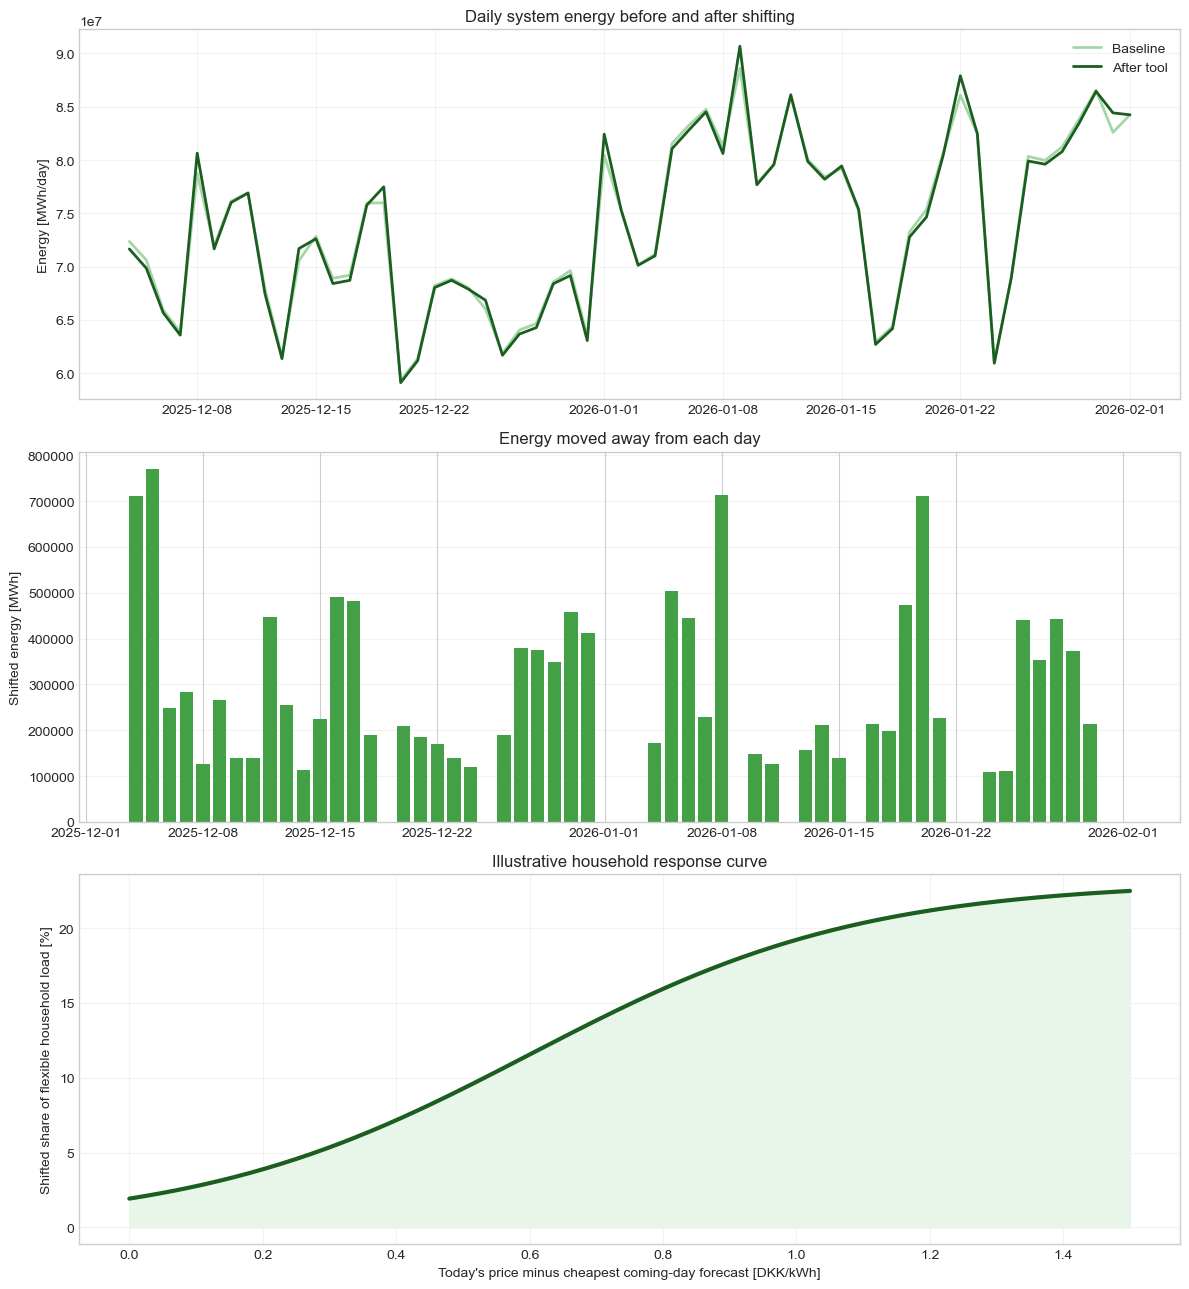

In [30]:
fig = plot_shift_results(shift_df)
plt.show()

The plots compare daily system energy before and after the simulated household response. The key interpretation is not that the exact number is a prediction, but that flexible household demand can act as a distributed resilience resource.

When households move some demand away from expensive periods, the system may experience lower peaks and a smoother load profile. This can support resilience by reducing stress during scarce or expensive periods and by making demand more responsive to system conditions.

## 8. Comparing Impact Sensitivity of the Forecast Model

Because the electricity price forecast is uncertain, we include a sensitivity analysis of the simulated grid impact. The question is: how much does the estimated resilience effect change if the forecasted future prices are systematically too low or too high?

This matters because households make shifting decisions based on predicted price differences. If the model underestimates or overestimates future prices, it may recommend too much or too little shifting. Comparing scenarios such as `-10% forecast bias`, `baseline`, and `+10% forecast bias` helps show how accurate the model needs to be for the recommender to support grid resilience reliably.

,forecast_bias,shifted_energy_mwh,peak_reduction_daily_mwh,residential_cost_savings_dkk,residential_cost_savings_pct
scenario,,,,,
-10%,-0.1,1.711043e+07,-2.395176e+06,5.540403e+09,0.005085
+0%,0.0,1.457743e+07,-2.062913e+06,5.025718e+09,0.004613
+10%,0.1,1.187571e+07,-1.758406e+06,4.495071e+09,0.004126


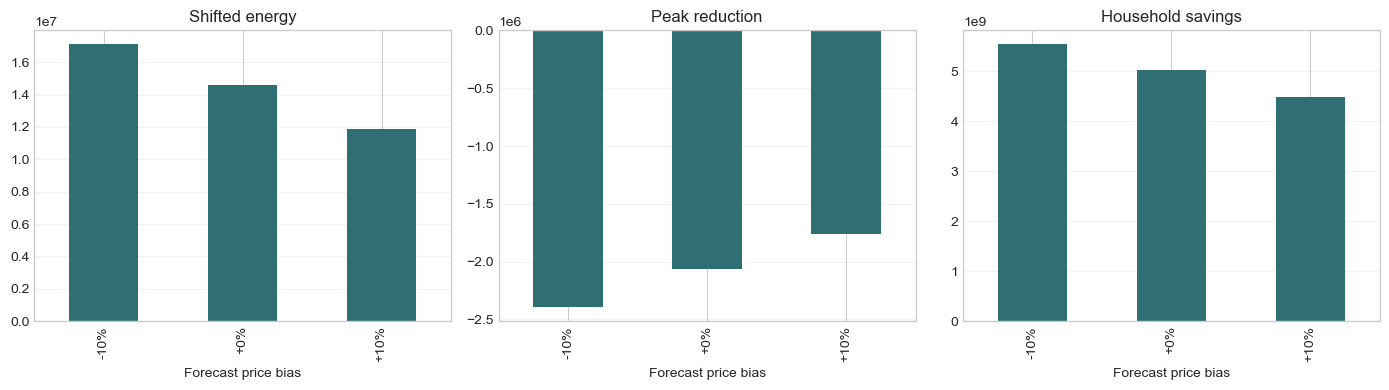

In [31]:
def recompute_shift_with_forecast_bias(base_df, forecast_bias=0.0):
    """Recompute the daily shifting result after changing forecasted future prices."""
    df = base_df.copy()
    forecast_price = df["forecast_price_dkk_per_mwh"].to_numpy() * (1 + forecast_bias)
    price_today = df["price_today_dkk_per_mwh"].to_numpy()
    household_daily = df["household_daily_energy_baseline_mwh"].to_numpy()
    flexible_daily = df["flexible_daily_energy_mwh"].to_numpy()
    system_daily = df["system_daily_energy_baseline_mwh"].to_numpy()
    other_daily = system_daily - household_daily

    household_shifted = household_daily.copy()
    shifted_out = np.zeros(len(df))
    shifted_in = np.zeros(len(df))

    lookahead_days = int(shift_summary["lookahead_days"])
    responsive_household_share = 0.33
    max_shift_fraction_of_flexible = 0.70
    midpoint_dkk_kwh = 0.60
    steepness = 4.0

    for t in range(len(df)):
        end = min(len(df), t + 1 + lookahead_days)
        if t + 1 >= end:
            continue

        future_slice = slice(t + 1, end)
        target = (t + 1) + np.argmin(forecast_price[future_slice])
        spread_dkk_kwh = (price_today[t] - forecast_price[target]) / 1000.0

        if spread_dkk_kwh <= 0:
            continue

        response = responsive_household_share * max_shift_fraction_of_flexible
        response *= 1.0 / (1.0 + np.exp(-steepness * (spread_dkk_kwh - midpoint_dkk_kwh)))
        shift_mwh = flexible_daily[t] * response

        household_shifted[t] -= shift_mwh
        household_shifted[target] += shift_mwh
        shifted_out[t] += shift_mwh
        shifted_in[target] += shift_mwh

    system_shifted = other_daily + household_shifted
    baseline_cost = np.sum(household_daily * price_today)
    shifted_cost = np.sum(household_shifted * price_today)

    return {
        "forecast_bias": forecast_bias,
        "scenario": f"{forecast_bias:+.0%}",
        "shifted_energy_mwh": shifted_out.sum(),
        "peak_reduction_daily_mwh": system_daily.max() - system_shifted.max(),
        "residential_cost_savings_dkk": baseline_cost - shifted_cost,
        "residential_cost_savings_pct": (baseline_cost - shifted_cost) / baseline_cost,
    }


sensitivity_summary = pd.DataFrame(
    [recompute_shift_with_forecast_bias(shift_df, bias) for bias in [-0.10, 0.00, 0.10]]
).set_index("scenario")

display(sensitivity_summary)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics_to_plot = [
    "shifted_energy_mwh",
    "peak_reduction_daily_mwh",
    "residential_cost_savings_dkk",
]
titles = ["Shifted energy", "Peak reduction", "Household savings"]

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    sensitivity_summary[metric].plot(kind="bar", ax=ax, color="#2F6F73")
    ax.set_title(title)
    ax.set_xlabel("Forecast price bias")
    ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

The sensitivity figures show how the estimated impact changes when the model's future price forecasts are shifted downward or upward. If future prices are forecast too low, the model sees more attractive saving opportunities and recommends more shifting. If future prices are forecast too high, fewer future periods look cheap, so the simulated household response becomes weaker.

This result is important for the resilience argument. The forecasting model does not need to predict every price perfectly, but it does need to capture the direction and relative size of upcoming price changes. A useful 5-day trend forecast can support household action, while a biased forecast can reduce the quality of recommendations and weaken the simulated grid benefit.

## 9. Discussion: Resilience Contribution

The project contributes to grid resilience in three ways.

First, it improves **situational awareness** by using historical electricity data to describe and forecast price patterns. Prices are not a perfect measure of grid stress, but they often reflect scarcity, congestion, and changing supply-demand conditions.

Second, it improves **decision quality** for households. Rather than asking consumers to manually inspect price tables, the recommendation layer converts analytics into short and actionable guidance.

Third, it supports **demand flexibility**. If many households shift flexible consumption, the aggregated effect can reduce peaks and make demand less rigid. This matters in an electricity system with high renewable production, where both supply and demand need to become more adaptive.

## 10. Assumptions and Limitations

This draft has several important limitations that should be discussed in the final hand-in.

- The household response model is scenario-based, not estimated from observed household behavior.
- The simulation uses daily aggregation, while real household flexibility often happens within the day.
- Price is used as the main signal, although grid stress also depends on local network constraints, production mix, weather, and interconnector flows.
- The recommendation example in this notebook uses a forecast-like table for demonstration. A final version should connect directly to a trained forecasting model if the model module is completed.
- Flexible consumption is assumed to be shifted rather than cancelled, which is reasonable for tasks such as EV charging and appliances but less accurate for all load types.

These limitations do not remove the project value. They clarify what the model can and cannot claim: it is best understood as a decision-support and impact-simulation framework for exploring household flexibility as a resilience resource.

## 11. Conclusion

This project shows how business analytics can connect data, forecasting, recommendations, and system-level impact. The technical workflow starts with DK1 electricity price and consumption data, builds time-series features, translates price signals into household guidance, and simulates how flexible demand could shift across days.

The main conclusion is that household flexibility can contribute to energy-grid resilience when analytics are made actionable. Forecasts create information, recommendations create usable decisions, and coordinated household response can help reduce system stress.